**Install Library and package**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk sastrawi wordcloud torch tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00


Import Library

In [ ]:
import pandas as pd #nampilin data, olah statistik
import numpy as np #olah statistil
import re # cleaning data
import string

#menampilkan visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

#evaluasi sama misahin data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

#token
import nltk
from nltk.tokenize import word_tokenize

#stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

#tampilin kata kata sering muncul
from wordcloud import WordCloud

# pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Load Dataset**

In [ ]:
df = pd.read_csv('youtube_comments.csv')
df.head()

,text,likes,published
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z


**cek ukuran dataset**

In [ ]:
print(df.shape)

(8727, 3)


**info dataset**

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8727 entries, 0 to 8726
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       8727 non-null   object
 1   likes      8727 non-null   int64 
 2   published  8727 non-null   object
dtypes: int64(1), object(2)
memory usage: 204.7+ KB
None


In [ ]:
df.describe()

,likes
count,8727.000000
mean,1.691074
std,12.042713
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,491.000000


In [ ]:
#Cleaning Dataset
# print(df.isnull().sum())
# print(df.duplicated().sum())
# df = df.dropna()
# df = df.drop_duplicates()

Rename column

In [ ]:
df = df.rename(columns={
    'text': 'comment'
})

check dataset

In [ ]:
df.head()

,comment,likes,published
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z


import stopword Indonesia

In [ ]:
import requests
stopwords_url = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_stop_words.txt"

response = requests.get(stopwords_url)

stopwords = response.text.splitlines()

stopwords = set(stopwords)

print(list(stopwords)[:10])

['setengah', 'baru', 'awalnya', 'pasti', 'mencari', 'karenanya', 'tutur', 'menyatakan', 'minggu', 'memungkinkan']


Import slang Indonesia

In [ ]:
slang_url = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt"

response = requests.get(slang_url)

slang_lines = response.text.splitlines()

In [ ]:
import json

slang_dict = {}

if slang_lines:
    try:
        slang_dict = json.loads(slang_lines[0])
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from slang_lines: {e}")

print(list(slang_dict.items())[:10])

[('@', 'di'), ('abis', 'habis'), ('ad', 'ada'), ('adlh', 'adalah'), ('afaik', 'as far as i know'), ('ahaha', 'haha'), ('aj', 'saja'), ('ajep-ajep', 'dunia gemerlap'), ('ak', 'saya'), ('akika', 'aku')]


Import Inset lexicon for labeling sentiment

InSet (Indonesia Sentiment Lexicon) adalah kamus sentimen
Bahasa Indonesia yang berisi:
  
   • positive.tsv → 3.609 kata positif dengan bobot +1 s/d +5

   • negative.tsv → 6.609 kata negatif dengan bobot -5 s/d -1

 Kedua file dibaca langsung dari GitHub (fajri91/InSet) tanpa
 perlu download manual. Format TSV (Tab-Separated Values) dibaca
 dengan sep='\t'.

 Kolom yang ada di setiap file:
  
  word   → kata dalam Bahasa Indonesia
  
  weight → bobot sentimen (bilangan bulat)

Contoh isi positive.tsv:   hai → +3, detail → +2

Contoh isi negative.tsv:   isak → -5, gelebah → -2

In [ ]:
positive = pd.read_csv(
    "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv",
    sep='\t'
)

negative = pd.read_csv(
    "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv",
    sep='\t'
)

In [ ]:
positive.head()

,word,weight
0,hai,3
1,merekam,2
2,ekstensif,3
3,paripurna,1
4,detail,2


In [ ]:
negative.head()

,word,weight
0,putus tali gantung,-2
1,gelebah,-2
2,gobar hati,-2
3,tersentuh (perasaan),-1
4,isak,-5


Combine Lexicon Into a Dictionary

In [ ]:
lexicon = {}

for index, row in positive.iterrows():
    lexicon[row['word']] = row['weight']

for index, row in negative.iterrows():
    lexicon[row['word']] = row['weight']


print(list(lexicon.items())[:10])

[('hai', 3), ('merekam', 2), ('ekstensif', 3), ('paripurna', 1), ('detail', 2), ('pernik', 3), ('belas', -3), ('welas', -3), ('kabung', -5), ('rahayu', -2)]


Import Stemming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

Text Pre Processing

In [ ]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove url
    text = re.sub(r'http\S+', '', text)

    # remove mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove angka
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove emoji
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenization
    tokens = word_tokenize(text)

    # stopword removal
    tokens = [
        word for word in tokens
        if word not in stopwords
    ]

    # stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    return ' '.join(tokens)

In [ ]:
df['clean_comment'] = df['comment'].apply(clean_text)

In [ ]:
df.head(100)

,comment,likes,published,clean_comment
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang
...,...,...,...,...
95,"Iya Pak wo,, benar masyrakat ndak pake dolar.....",0,2026-05-16T23:54:54Z,iya wo benar masyrakat ndak pake dolar korban ...
96,Indo sangat mudah sekali akan terus terbodohi ...,0,2026-05-16T23:06:33Z,indo mudah bodoh ubah nyata gak kpda rakyat ke...
97,NELAYAN ORANG DESA DIESEL NAIK DOLAR 30 RIBU N...,0,2026-05-16T22:02:47Z,nelayan desa diesel dolar nelayan g laut rajin...
98,"Makin bnyk Omong makin eneg liat nya ,",0,2026-05-16T21:06:32Z,bnyk omong eneg liat nya


Sentiment Labelling


Function for score sentiment

In [ ]:
def sentiment_score(text):

    words = text.split()

    score = 0

    for word in words:

        if word in lexicon:
            score += lexicon[word]

    return score

Sentiment Label

In [ ]:
def sentiment_label(score):

    if score > 0:
        return 'positive'

    elif score < 0:
        return 'negative'

    else:
        return 'neutral'

In [ ]:
df['score'] = df['clean_comment'].apply(
    sentiment_score
)

In [ ]:
df.head(100)

,comment,likes,published,clean_comment,score
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane,1
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...,-7
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh,-9
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong,0
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang,-11
...,...,...,...,...,...
95,"Iya Pak wo,, benar masyrakat ndak pake dolar.....",0,2026-05-16T23:54:54Z,iya wo benar masyrakat ndak pake dolar korban ...,-18
96,Indo sangat mudah sekali akan terus terbodohi ...,0,2026-05-16T23:06:33Z,indo mudah bodoh ubah nyata gak kpda rakyat ke...,-24
97,NELAYAN ORANG DESA DIESEL NAIK DOLAR 30 RIBU N...,0,2026-05-16T22:02:47Z,nelayan desa diesel dolar nelayan g laut rajin...,-3
98,"Makin bnyk Omong makin eneg liat nya ,",0,2026-05-16T21:06:32Z,bnyk omong eneg liat nya,-5


**EDA**

Sentiment Distribution

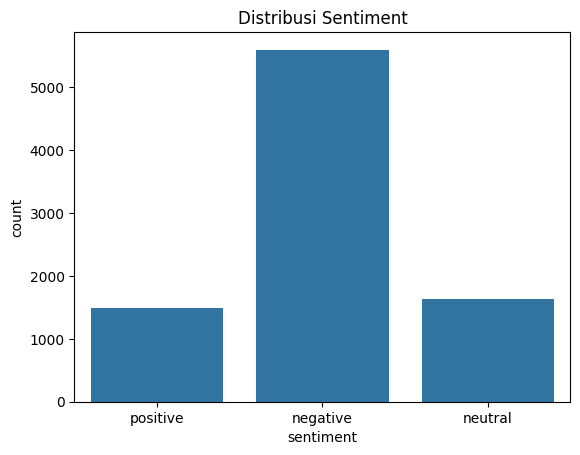

In [ ]:
df['sentiment'] = df['score'].apply(sentiment_label)
sns.countplot(
    data=df,
    x='sentiment'
)

plt.title('Distribusi Sentiment')
plt.show()

Comment Length Distribution

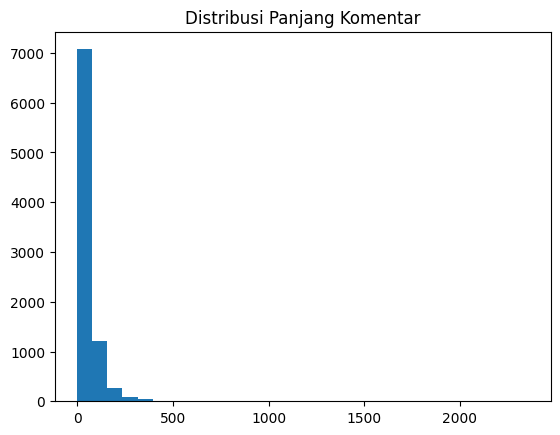

In [ ]:
df['length'] = df['clean_comment'].apply(len)

plt.hist(df['length'], bins=30)

plt.title('Distribusi Panjang Komentar')

plt.show()

Most Common Words

In [ ]:
all_words = ' '.join(
    df['clean_comment']
).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(10)

common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

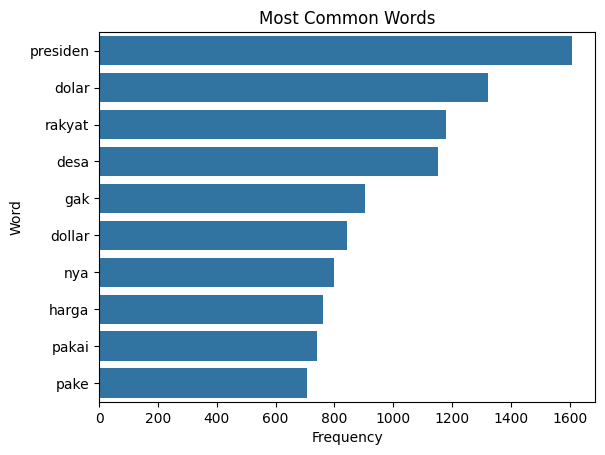

In [ ]:
sns.barplot(
    data=common_df,
    x='Frequency',
    y='Word'
)

plt.title('Most Common Words')

plt.show()

Common Words Visualization

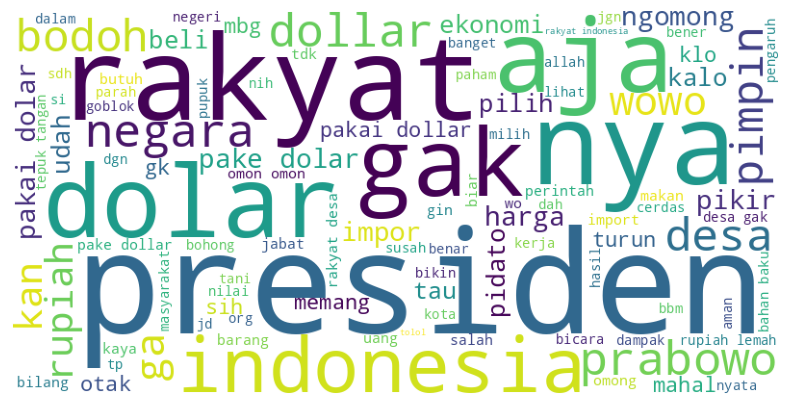

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(
    ' '.join(df['clean_comment'])
)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

Label Encoding

##### Model deep learning membutuhkan label dalam format angka,
###### bukan string. LabelEncoder mengkonversi:
######   'negative' → 0
######   'neutral'  → 1
######   'positive' → 2
###### (urutan alphabetical secara default)
#
###### fit_transform() = fit (pelajari mapping) + transform (terapkan)
###### Hasilnya disimpan ke kolom baru 'label'.

In [ ]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(
    df['sentiment']
)

In [ ]:
df.head()

,comment,likes,published,clean_comment,score,sentiment,length,label
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane,1,positive,30,2
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...,-7,negative,53,0
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh,-9,negative,32,0
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong,0,neutral,25,1
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang,-11,negative,22,0


Label Mapping

In [ ]:
mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(
            encoder.classes_
        )
    )
)

print(mapping)

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


Build Vocabulary

 Vocabulary (kamus kata) adalah pemetaan dari kata → angka unik.
###### Dibangun dari seluruh kata dalam dataset.
#
###### Token spesial yang wajib ada:
######   <"PAD"> → index 0 : digunakan untuk padding (mengisi komentar
######             pendek agar panjangnya sama)
######   <"UNK"> → index 1 : unknown token, untuk kata yang tidak
######             pernah muncul di training set
#
###### Setiap kata baru akan mendapat index unik mulai dari 2.

In [ ]:
vocab = {
    '<PAD>': 0,
    '<UNK>': 1
}

Generate Vocabulary

In [ ]:
df['tokens'] = df['clean_comment'].apply(word_tokenize)

idx = 2

for tokens in df['tokens']:

    for token in tokens:

        if token not in vocab:

            vocab[token] = idx

            idx += 1

In [ ]:
df.head()

,comment,likes,published,clean_comment,score,sentiment,length,label,tokens
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane,1,positive,30,2,"[banget, temen, rika, kangpikirane]"
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...,-7,negative,53,0,"[pasuk, umur, lucu, nya, semenjak, jokowi, ind..."
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh,-9,negative,32,0,"[pgn, ngatain, ni, org, dosa, tp, bodoh]"
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong,0,neutral,25,1,"[desa, barter, pake, singkong]"
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang,-11,negative,22,0,"[desa, utang, bayar, utang]"


In [ ]:
#vocab size
vocab_size = len(vocab)

print(vocab_size)

11459


Convert Tokens to Sequence

In [ ]:
def tokens_to_sequence(tokens):

    return [
        vocab.get(
            token,
            vocab['<UNK>']
        )

        for token in tokens
    ]

In [ ]:
df['sequence'] = df['tokens'].apply(
    tokens_to_sequence
)

In [ ]:
df.head()

,comment,likes,published,clean_comment,score,sentiment,length,label,tokens,sequence
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane,1,positive,30,2,"[banget, temen, rika, kangpikirane]","[2, 3, 4, 5]"
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...,-7,negative,53,0,"[pasuk, umur, lucu, nya, semenjak, jokowi, ind...","[6, 7, 8, 9, 10, 11, 12, 13]"
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh,-9,negative,32,0,"[pgn, ngatain, ni, org, dosa, tp, bodoh]","[14, 15, 16, 17, 18, 19, 20]"
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong,0,neutral,25,1,"[desa, barter, pake, singkong]","[21, 22, 23, 24]"
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang,-11,negative,22,0,"[desa, utang, bayar, utang]","[21, 25, 26, 25]"


Padding

Model deep learning membutuhkan input dengan panjang SAMA persis.
###### Fungsi pad_tokens() menyamakan panjang semua sequence ke MAX_LEN=100.
#
###### Dua skenario:
######   • Sequence LEBIH PENDEK dari 100:
######     → Tambah angka 0 (token <PAD>) di bagian akhir (post-padding)
######     → sequence + [0] * (100 - len(sequence))
#
######   • Sequence LEBIH PANJANG dari 100:

     → Potong di karakter ke-100 (truncation)

     → sequence[:100]
#
###### MAX_LEN = 100 dipilih berdasarkan distribusi panjang komentar.
###### Padding menggunakan index 0 = <PAD> yang sudah didefinisikan,
###### dan Embedding layer akan mengabaikan token ini (padding_idx=0).

In [ ]:
max_len = 200
def pad_tokens(sequence):

    if len(sequence) < max_len:

        sequence = sequence + \
            [0] * (
                max_len - len(sequence)
            )

    else:

        sequence = sequence[:max_len]

    return sequence

In [ ]:
df['padded'] = df['sequence'].apply(
    pad_tokens
)

In [ ]:
df['padded'].head()

,padded
0,"[2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[6, 7, 8, 9, 10, 11, 12, 13, 0, 0, 0, 0, 0, 0,..."
2,"[14, 15, 16, 17, 18, 19, 20, 0, 0, 0, 0, 0, 0,..."
3,"[21, 22, 23, 24, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,"[21, 25, 26, 25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
df.head()

,comment,likes,published,clean_comment,score,sentiment,length,label,tokens,sequence,padded
0,"Kebangetan temen rika kang,.pikirane",0,2026-05-17T14:06:00Z,banget temen rika kangpikirane,1,positive,30,2,"[banget, temen, rika, kangpikirane]","[2, 3, 4, 5]","[2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"Memasuki umur lucu² nya\n\nSemenjak Jokowi, In...",0,2026-05-17T13:17:40Z,pasuk umur lucu nya semenjak jokowi indonesa i...,-7,negative,53,0,"[pasuk, umur, lucu, nya, semenjak, jokowi, ind...","[6, 7, 8, 9, 10, 11, 12, 13]","[6, 7, 8, 9, 10, 11, 12, 13, 0, 0, 0, 0, 0, 0,..."
2,"Pgn ngatain ni org dosa, tp kok bodoh ya",0,2026-05-17T12:40:39Z,pgn ngatain ni org dosa tp bodoh,-9,negative,32,0,"[pgn, ngatain, ni, org, dosa, tp, bodoh]","[14, 15, 16, 17, 18, 19, 20]","[14, 15, 16, 17, 18, 19, 20, 0, 0, 0, 0, 0, 0,..."
3,Ya di desa barter pake singkong,0,2026-05-17T12:26:26Z,desa barter pake singkong,0,neutral,25,1,"[desa, barter, pake, singkong]","[21, 22, 23, 24]","[21, 22, 23, 24, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,Orang desa tidak ikut utang tapi ikut bayar utang,1,2026-05-17T12:03:23Z,desa utang bayar utang,-11,negative,22,0,"[desa, utang, bayar, utang]","[21, 25, 26, 25]","[21, 25, 26, 25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
X = list(df['padded'])

y = df['label'].values

Train Test Split Data

Dataset dibagi menjadi 3 bagian:
#
##### Split 1: train_test_split(test_size=0.2)
#####   → 80% data  = Training + Validation
#####   → 20% data  = Testing               
#####   stratify=y : menjaga proporsi kelas tetap sama di setiap split
#
##### Split 2: train_test_split(test_size=0.1) dari bagian training
#####   → 90% dari 80% = Training  
#####   → 10% dari 80% = Validation
#
##### Fungsi masing-masing:
#####   Train      → data untuk melatih model (update bobot)
#####   Validation → memantau overfitting saat training (tidak dilatih)
#####   Test       → evaluasi akhir model (tidak pernah dilihat model)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

Convert to Tensor

 PyTorch bekerja dengan objek Tensor, bukan list Python atau
##### numpy array biasa. Konversi dilakukan dengan torch.tensor().
#
###### dtype=torch.long (int64) dipilih karena:
######   → X (sequences) adalah integer (indeks vocab) → long
######   → y (labels) adalah integer (0,1,2)           → long
#
###### Mengapa bukan float?
######   → Embedding layer mengharapkan indeks integer (Long Tensor)
######   → CrossEntropyLoss mengharapkan label integer (Long Tensor)
#

In [ ]:
X_train = torch.tensor(
    X_train,
    dtype=torch.long
)

X_val = torch.tensor(
    X_val,
    dtype=torch.long
)

X_test = torch.tensor(
    X_test,
    dtype=torch.long
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

print(X_train)

torch.Size([5584, 200])
torch.Size([1397, 200])
torch.Size([1746, 200])
torch.Size([5584])
torch.Size([1397])
torch.Size([1746])
tensor([[ 309,  648,  128,  ...,    0,    0,    0],
        [ 309, 2057,  572,  ...,    0,    0,    0],
        [ 315, 4595,  321,  ...,    0,    0,    0],
        ...,
        [ 287,  581, 1866,  ...,    0,    0,    0],
        [1399, 4109,   23,  ...,    0,    0,    0],
        [7613, 3961, 2000,  ...,    0,    0,    0]])


Dataset Class

PyTorch menggunakan kelas Dataset sebagai antarmuka standar
###### untuk mengelola data. Kelas CommentDataset mewarisi torch.utils.data.Dataset
###### dan wajib mengimplementasikan 3 method:
#
######   __init__(X, y)    → menyimpan data ke atribut objek
######   __len__()         → mengembalikan jumlah total sampel
######   __getitem__(idx)  → mengembalikan satu pasang (input, label)
######                       berdasarkan index idx
#
###### Manfaat menggunakan Dataset class:
######   → DataLoader dapat mengambil data secara otomatis per batch
######   → Mendukung shuffle, parallel loading, dan augmentasi data

In [ ]:
class CommentDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

DataLoader

DataLoader mengotomatisasi proses batching saat training.
#
##### Parameter penting:
######   batch_size=32 → ambil 32 sampel setiap iterasi training
######                   (trade-off: besar=cepat tapi butuh RAM lebih)
######   shuffle=True  → acak urutan data SETIAP EPOCH pada train_loader
######                   → mencegah model hafal urutan data
######   shuffle=False → val & test TIDAK diacak (evaluasi konsisten)
#
###### DataLoader dibuat untuk 3 subset:
######   train_loader → digunakan saat training (shuffle=True)
######   val_loader   → digunakan saat validasi (shuffle=False)
######   test_loader  → digunakan saat evaluasi akhir (shuffle=False)

In [ ]:
train_dataset = CommentDataset(
    X_train,
    y_train
)

val_dataset = CommentDataset(
    X_val,
    y_val
)

test_dataset = CommentDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

LSTM Model Class

Arsitektur model LSTM untuk klasifikasi sentimen:
#
##### [1] nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
######     → Mengubah integer indeks kata → vektor dense berdimensi 128
######     → Setiap kata direpresentasikan sebagai vektor angka
######     → padding_idx=0: token <PAD> tidak ikut update saat training
######     → Parameter: vocab_size × 128 weights
#
###### [2] nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
######     → Long Short-Term Memory: memproses sequence secara berurutan
######     → Mampu menangkap dependensi jarak jauh dalam kalimat
######     → batch_first=True: input shape (batch, seq_len, embed_dim)
######     → Output: output semua timestep + (hidden_state, cell_state)
######    → hidden[-1]: ambil hidden state dari layer terakhir
#
###### [3] nn.Dropout(0.3)
######     → Regularisasi: secara acak "matikan" 30% neuron saat training
######     → Mencegah overfitting (model terlalu hafal data training)
#
###### [4] nn.Linear(hidden_dim, output_dim)
######     → Fully Connected / Dense layer
######     → Mengubah hidden state (128 dim) → logit (3 kelas)
######     → Output belum di-softmax (CrossEntropyLoss sudah include softmax)
#
###### Forward pass:
######   Input (batch, 100) → Embedding → (batch, 100, 128)
######                      → LSTM     → hidden (batch, 128)
######                      → Dropout  → hidden (batch, 128)
######                      → FC       → logits (batch, 3)

In [ ]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.4)

        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(
            embedded
        )

        hidden = self.dropout(
            hidden[-1]
        )

        out = self.fc(hidden)

        return out

GRU Model Class

Arsitektur GRU identik dengan LSTM, bedanya hanya pada layer RNN:
#
###### nn.GRU vs nn.LSTM:
######   • GRU (Gated Recurrent Unit) memiliki 2 gate: reset & update
######   • LSTM memiliki 3 gate: input, forget, output + cell state
######   • GRU lebih ringan (lebih sedikit parameter)
######  • GRU biasanya konvergen lebih cepat
######   • LSTM potensial lebih baik untuk sequence panjang
#
###### Perbedaan output:
######   LSTM → output, (hidden, cell)   ← ada cell state
######   GRU  → output, hidden           ← tanpa cell state
#
###### Konfigurasi identik agar perbandingan FAIR:
######   embedding_dim = 128, hidden_dim = 128, dropout = 0.3

In [ ]:
class GRUModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.gru(
            embedded
        )

        hidden = self.dropout(
            hidden[-1]
        )

        out = self.fc(hidden)

        return out

In [ ]:
device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

hyperparameters

 Hyperparameter adalah nilai konfigurasi yang ditentukan
# sebelum training dimulai (tidak diupdate oleh backpropagation).
#
#####   embedding_dim = 128
#####     → Dimensi vektor representasi tiap kata
#####    → Semakin besar: representasi lebih kaya, tapi lebih lambat
#
#####   hidden_dim = 128
#####    → Ukuran hidden state LSTM/GRU
#####     → Menentukan "kapasitas memori" model untuk konteks
#
#####   output_dim = 3
#####     → Jumlah kelas output (negative, neutral, positive)
#
#####   learning_rate = 0.001
#####    → Seberapa besar langkah update weight per iterasi
##### → Terlalu besar: tidak konvergen | Terlalu kecil: lambat
#####  → 0.001 adalah default Adam yang terbukti baik
#
#####  epochs = 10
#####   → Berapa kali model melihat seluruh data training
#####    → Di dataset besar biasanya 10-30 epoch sudah cukup

In [ ]:

embedding_dim = 256
hidden_dim = 256
output_dim = 3

learning_rate = 0.0001
epochs = 50

Create calculate accuracy function

In [ ]:
def calculate_accuracy(preds, labels):

    _, predicted = torch.max(preds, 1)

    correct = (
        predicted == labels
    ).sum().item()

    acc = correct / len(labels)

    return acc

Createtraining model  function

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device
):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # TRAINING
        model.train()

        total_train_loss = 0
        total_train_acc = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            acc = calculate_accuracy(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()
            total_train_acc += acc

        avg_train_loss = (
            total_train_loss /
            len(train_loader)
        )

        avg_train_acc = (
            total_train_acc /
            len(train_loader)
        )

        # VALIDATION
        model.eval()

        total_val_loss = 0
        total_val_acc = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    labels
                )

                acc = calculate_accuracy(
                    outputs,
                    labels
                )

                total_val_loss += loss.item()
                total_val_acc += acc

        avg_val_loss = (
            total_val_loss /
            len(val_loader)
        )

        avg_val_acc = (
            total_val_acc /
            len(val_loader)
        )

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        train_accuracies.append(avg_train_acc)
        val_accuracies.append(avg_val_acc)

        print(f'''
Epoch {epoch+1}/{epochs}

Train Loss : {avg_train_loss:.4f}
Train Acc  : {avg_train_acc:.4f}

Val Loss   : {avg_val_loss:.4f}
Val Acc    : {avg_val_acc:.4f}
''')

    history = {

        'train_loss': train_losses,
        'val_loss': val_losses,

        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }

    return history

Create evaluate model function

In [ ]:
def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for inputs, labels in test_loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            _, preds = torch.max(
                outputs,
                1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            actuals.extend(
                labels.numpy()
            )

    print(
        classification_report(
            actuals,
            predictions
        )
    )

    cm = confusion_matrix(
        actuals,
        predictions
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.title(
        'Confusion Matrix'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    acc = accuracy_score(
        actuals,
        predictions
    )

    print(f'Accuracy: {acc:.4f}')

    return acc

In [ ]:
def plot_history(history, model_name):

    epochs_range = range(
        1,
        len(history['train_loss']) + 1
    )

    # LOSS
    plt.figure(figsize=(10,5))

    plt.plot(
        epochs_range,
        history['train_loss'],
        label='Train Loss'
    )

    plt.plot(
        epochs_range,
        history['val_loss'],
        label='Validation Loss'
    )

    plt.title(
        f'{model_name} Loss'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.legend()

    plt.show()

    # ACCURACY
    plt.figure(figsize=(10,5))

    plt.plot(
        epochs_range,
        history['train_acc'],
        label='Train Accuracy'
    )

    plt.plot(
        epochs_range,
        history['val_acc'],
        label='Validation Accuracy'
    )

    plt.title(
        f'{model_name} Accuracy'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.legend()

    plt.show()

initialize model

In [ ]:
lstm_model = LSTMModel(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim
).to(device)

LSTM optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=learning_rate
)

Train LSTM Model

In [ ]:
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=lstm_optimizer,
    epochs=epochs,
    device=device
)


Epoch 1/50

Train Loss : 0.9686
Train Acc  : 0.5832

Val Loss   : 0.8864
Val Acc    : 0.6522


Epoch 2/50

Train Loss : 0.9065
Train Acc  : 0.6395

Val Loss   : 0.8867
Val Acc    : 0.6522


Epoch 3/50

Train Loss : 0.9058
Train Acc  : 0.6391

Val Loss   : 0.8884
Val Acc    : 0.6522


Epoch 4/50

Train Loss : 0.9104
Train Acc  : 0.6395

Val Loss   : 0.8885
Val Acc    : 0.6522


Epoch 5/50

Train Loss : 0.9064
Train Acc  : 0.6391

Val Loss   : 0.8872
Val Acc    : 0.6522


Epoch 6/50

Train Loss : 0.9066
Train Acc  : 0.6386

Val Loss   : 0.8896
Val Acc    : 0.6522


Epoch 7/50

Train Loss : 0.9068
Train Acc  : 0.6389

Val Loss   : 0.8865
Val Acc    : 0.6522


Epoch 8/50

Train Loss : 0.9050
Train Acc  : 0.6396

Val Loss   : 0.8888
Val Acc    : 0.6522


Epoch 9/50

Train Loss : 0.9059
Train Acc  : 0.6393

Val Loss   : 0.8878
Val Acc    : 0.6522


Epoch 10/50

Train Loss : 0.9047
Train Acc  : 0.6396

Val Loss   : 0.8872
Val Acc    : 0.6522


Epoch 11/50

Train Loss : 0.9054
Train Acc  : 0.

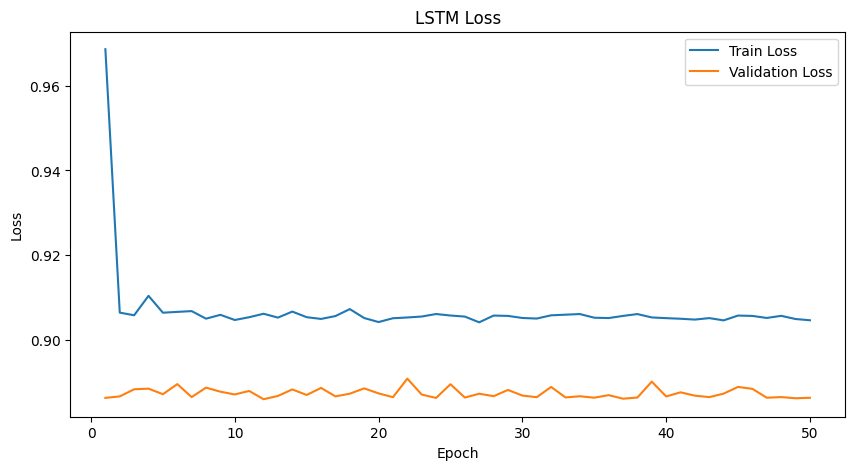

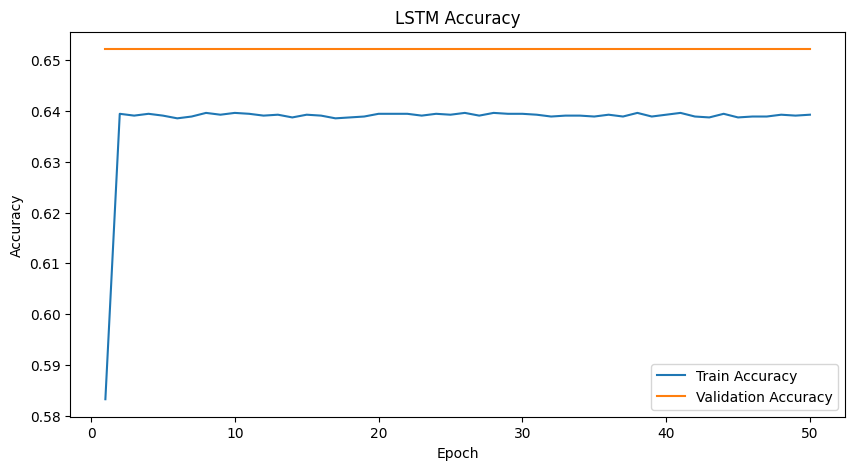

In [ ]:
plot_history(
    lstm_history,
    'LSTM'
)

              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1120
           1       0.00      0.00      0.00       327
           2       0.00      0.00      0.00       299

    accuracy                           0.64      1746
   macro avg       0.21      0.33      0.26      1746
weighted avg       0.41      0.64      0.50      1746



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


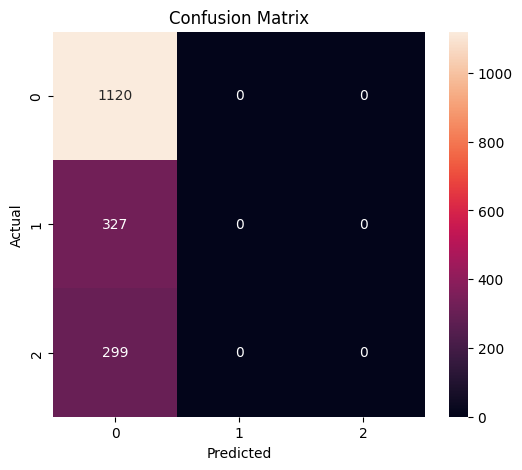

Accuracy: 0.6415


In [ ]:
#Evaluate LSTM
lstm_acc = evaluate_model(
    lstm_model,
    test_loader,
    device
)

Initialize gru

In [ ]:
gru_model = GRUModel(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim
).to(device)

In [ ]:
gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=learning_rate
)

Train GRU Model

In [ ]:
gru_history = train_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=gru_optimizer,
    epochs=epochs,
    device=device
)


Epoch 1/50

Train Loss : 0.9532
Train Acc  : 0.6032

Val Loss   : 0.9004
Val Acc    : 0.6522


Epoch 2/50

Train Loss : 0.9077
Train Acc  : 0.6389

Val Loss   : 0.8866
Val Acc    : 0.6522


Epoch 3/50

Train Loss : 0.9079
Train Acc  : 0.6384

Val Loss   : 0.8921
Val Acc    : 0.6522


Epoch 4/50

Train Loss : 0.9057
Train Acc  : 0.6389

Val Loss   : 0.8869
Val Acc    : 0.6522


Epoch 5/50

Train Loss : 0.9058
Train Acc  : 0.6388

Val Loss   : 0.8874
Val Acc    : 0.6522


Epoch 6/50

Train Loss : 0.9051
Train Acc  : 0.6396

Val Loss   : 0.8861
Val Acc    : 0.6522


Epoch 7/50

Train Loss : 0.9050
Train Acc  : 0.6393

Val Loss   : 0.8859
Val Acc    : 0.6522


Epoch 8/50

Train Loss : 0.9051
Train Acc  : 0.6393

Val Loss   : 0.8864
Val Acc    : 0.6522


Epoch 9/50

Train Loss : 0.9063
Train Acc  : 0.6393

Val Loss   : 0.8874
Val Acc    : 0.6522


Epoch 10/50

Train Loss : 0.9050
Train Acc  : 0.6388

Val Loss   : 0.8887
Val Acc    : 0.6522


Epoch 11/50

Train Loss : 0.9048
Train Acc  : 0.

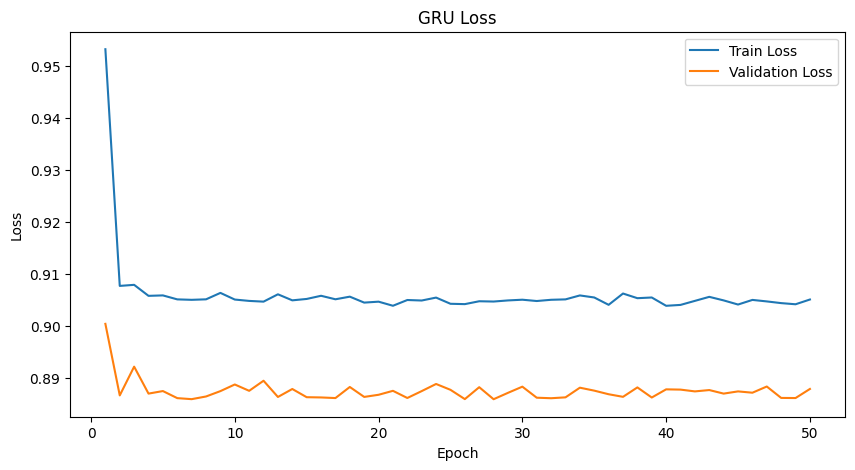

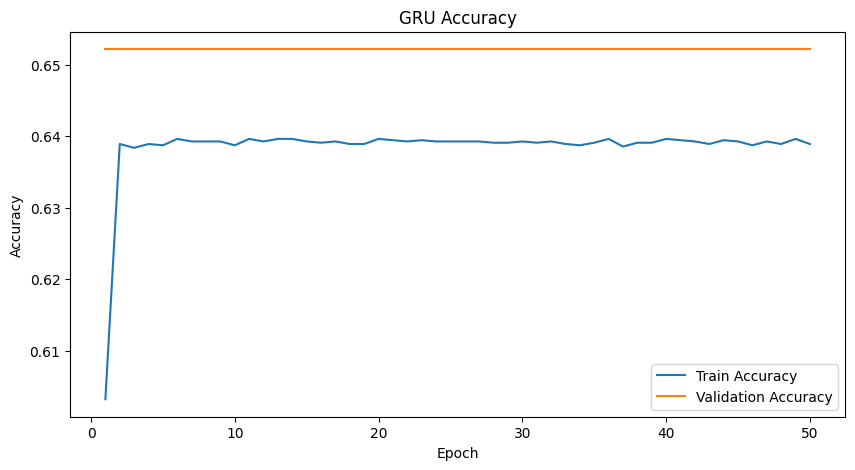

In [ ]:
plot_history(
    gru_history,
    'GRU'
)

              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1120
           1       0.00      0.00      0.00       327
           2       0.00      0.00      0.00       299

    accuracy                           0.64      1746
   macro avg       0.21      0.33      0.26      1746
weighted avg       0.41      0.64      0.50      1746



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


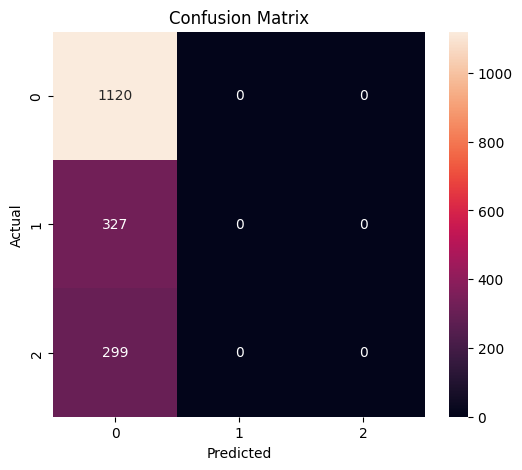

Accuracy: 0.6415


In [ ]:
gru_acc = evaluate_model(
    gru_model,
    test_loader,
    device
)

In [ ]:
print(f'''
LSTM Accuracy : {lstm_acc:.4f}
GRU Accuracy  : {gru_acc:.4f}
''')


LSTM Accuracy : 0.6415
GRU Accuracy  : 0.6415

